# Machine Learning Model for Overall Dataset

## Data Context

### Imports

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

%run "../utils/notebook_utils.py"
%run "../utils/feature_categories.py"

### Dataset Info

In [2]:
TRAINING_DATA = "../data/Training.parquet"
TARGET = "status"
full_data_frame = pd.read_parquet(TRAINING_DATA, engine='pyarrow')

### Dataset Statistics

In [3]:
full_data_frame.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.0,7658.000000,...,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7.658000e+03,7658.000000,7658.000000,7658.000000
mean,61.031993,20.998694,0.148211,2.468399,1.003265,0.021154,0.142596,0.159441,0.0,0.293419,...,0.126665,0.778532,0.438104,0.074432,495.550535,4053.276443,8.679665e+05,0.021154,0.529381,3.192740
std,58.652024,10.207985,0.355332,1.378526,2.055865,0.152714,0.366461,0.834974,0.0,1.020342,...,0.332619,0.415262,0.496186,0.262490,860.938768,3104.632489,2.016619e+06,0.143908,0.499169,2.542354
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,32.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,959.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,243.000000,3993.000000,2.161500e+03,0.000000,1.000000,3.000000
75%,70.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,442.750000,7006.000000,3.822200e+05,0.000000,1.000000,5.000000
max,1641.000000,213.000000,1.000000,24.000000,32.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.074572e+07,1.000000,1.000000,10.000000


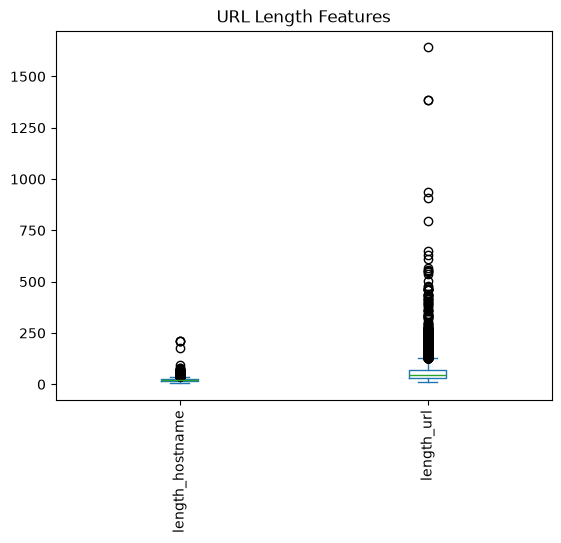

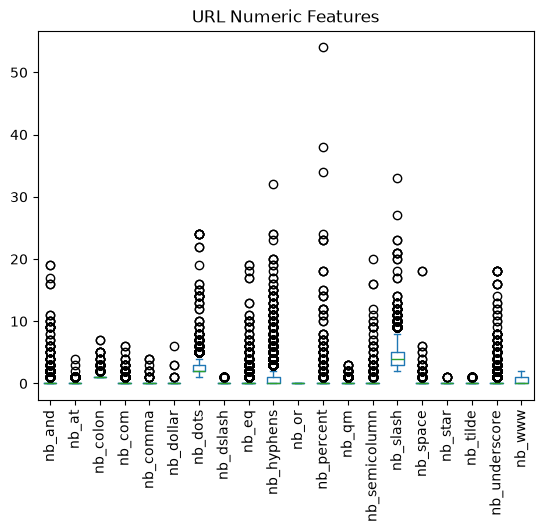

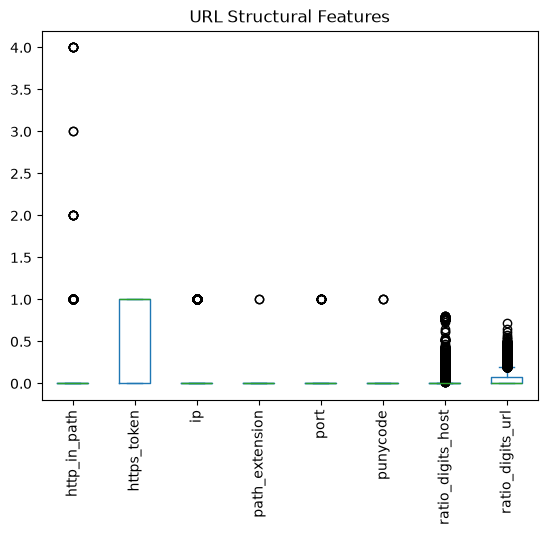

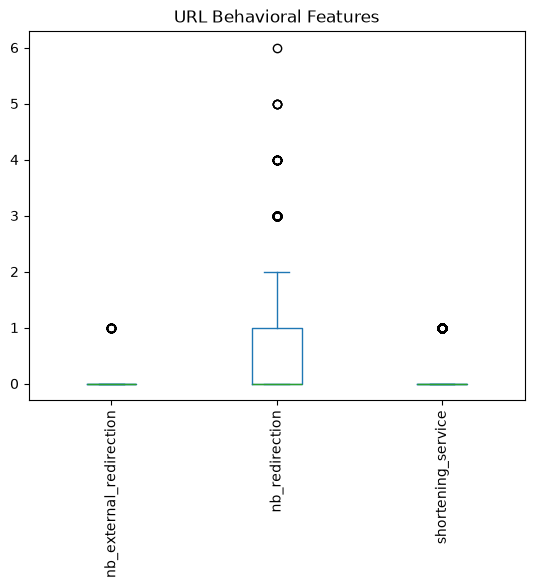

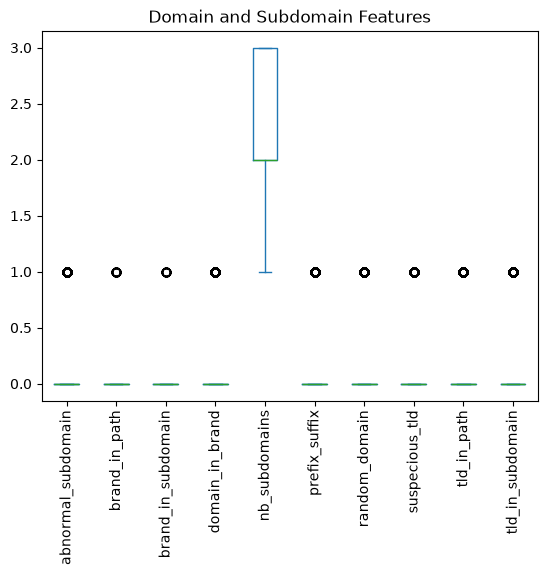

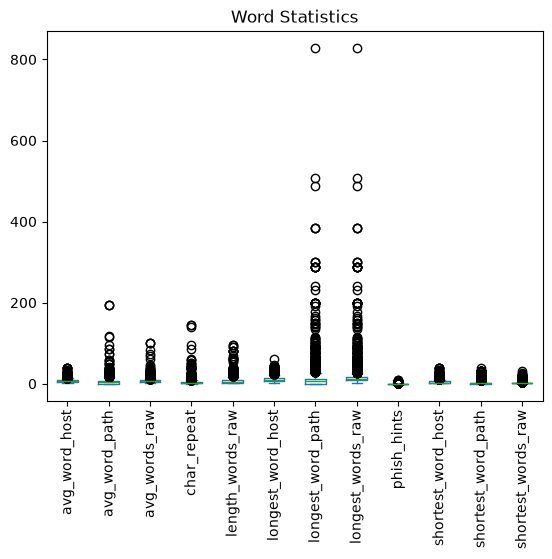

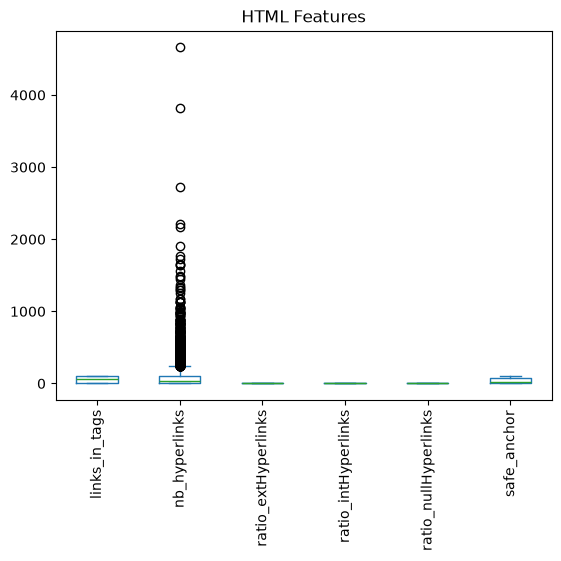

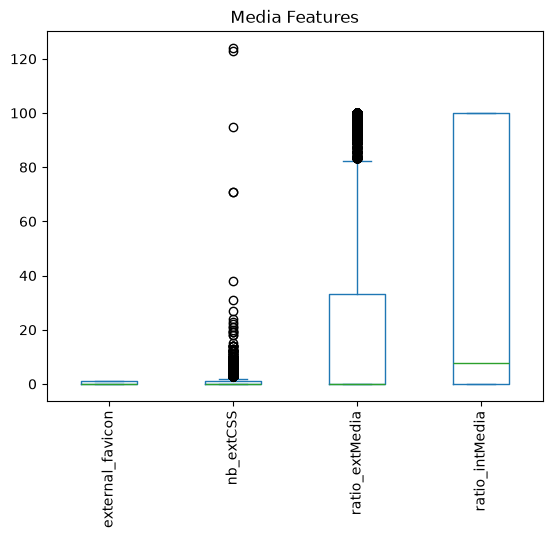

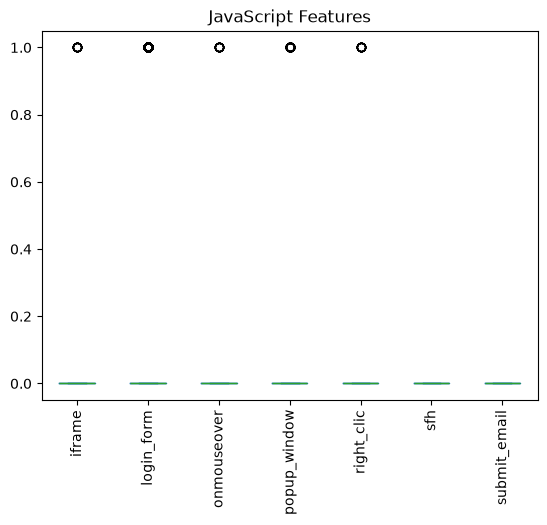

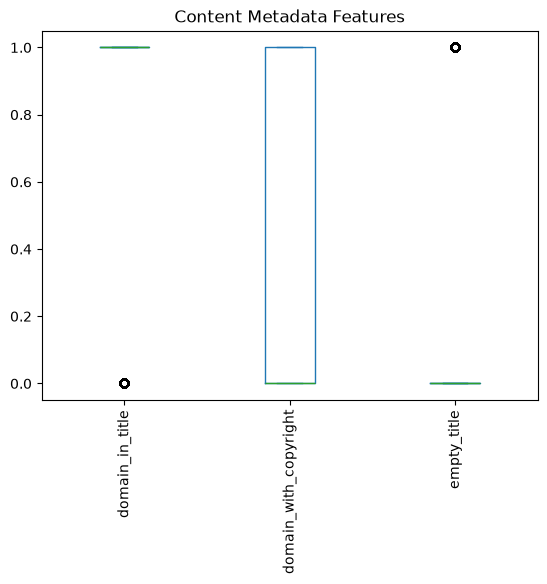

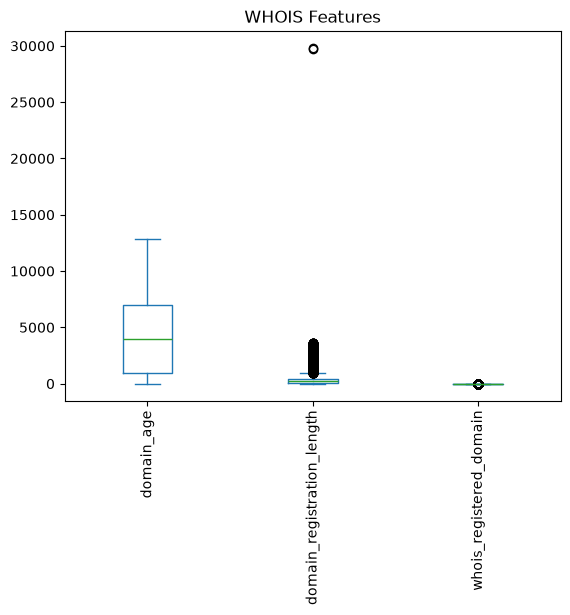

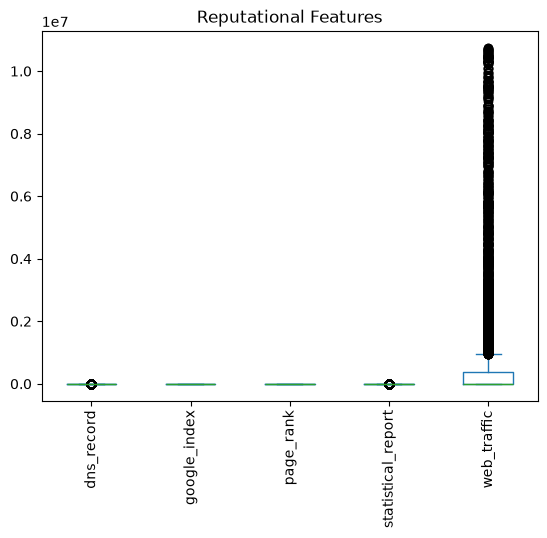

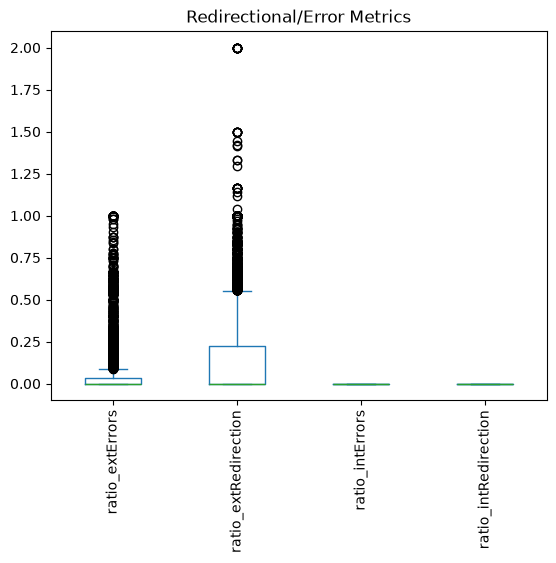

In [4]:
for title, columns in FEATURE_CATEGORIES.items():
    data_frame = generate_sub_data_frame(columns, add_status=False)
    frame_box_plot(
        data_frame, title
    )

### Boolean Attributes
These are attributes that indicate whether a specific feature is present or not present.

In [5]:
BOOLEAN_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 2)]. columns
)

len(BOOLEAN_ATTRIBUTES)

32

### Non-Boolean Attributes
These attributes are much more diverse and complex in comparison to boolean attributes. This includes numerical values asides from 0 and 1 and URLs themselves.

In [6]:
NON_BOOL_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() > 2)].columns
)

len(NON_BOOL_ATTRIBUTES)

51

In [7]:
MODEL_FILE_NAME = "random_forest_all"
MODEL_TITLE = "Random Forest w/ All Features"

save_stage_metrics(
    MODEL_TITLE,
    "Raw Data",
    MODEL_FILE_NAME,
    set(full_data_frame.columns),
    RandomForestClassifier(random_state=41)
)

## Removing Redundant Attributes

### Constant Features
These are features whose values are all the same across every URL and thereby serve no purpose in distinguishing between a phishing link and a legitimate link.

In [8]:
REDUNDANT_FEATURES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 1)].columns
)

save_redundant_features(REDUNDANT_FEATURES)

save_stage_metrics(
    MODEL_TITLE,
    "Remove Constant Features",
    MODEL_FILE_NAME,
    set(full_data_frame.columns) - set(REDUNDANT_FEATURES),
    RandomForestClassifier(random_state=41)
)

REDUNDANT_FEATURES

{'nb_or',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'sfh',
 'submit_email'}

Below we remove these features to address the curse of dimensionality.

In [9]:
RELEVANT_FEATURES = get_relevant_features(full_data_frame)

### Highly Correlated Features
These features can be identified visually via a correlation matrix.

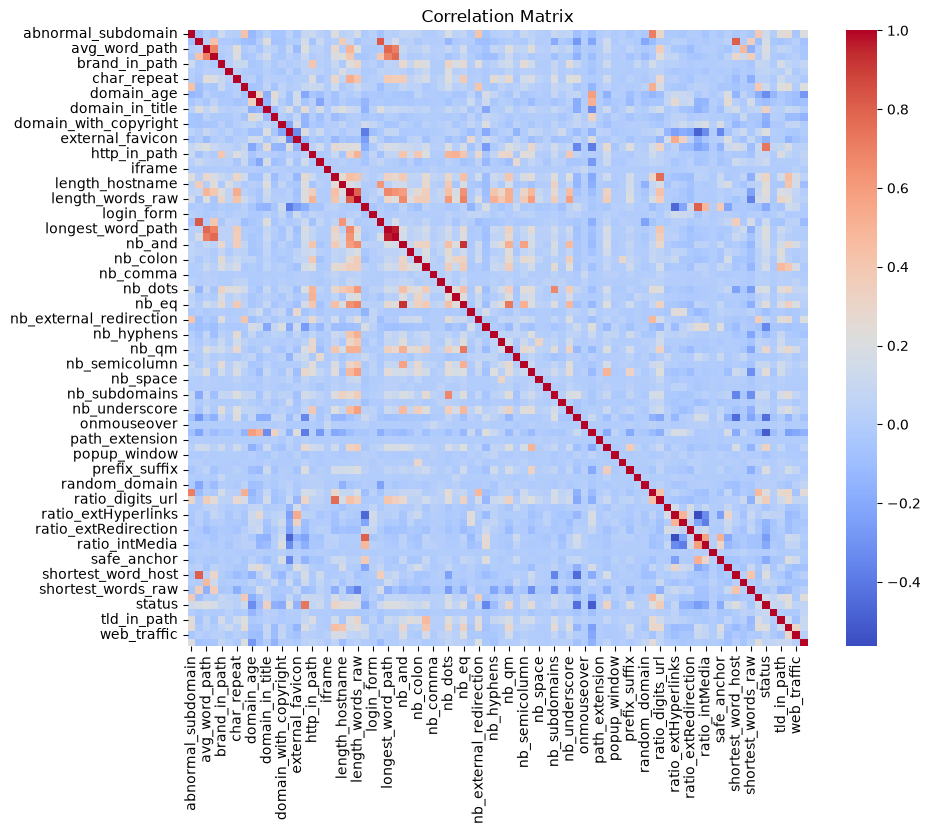

In [10]:
cleaned_data_frame_1 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_1, annotate=False)

#### Top 10 Highest Correlation Pairings

In [11]:
get_top_correlation_pairs(cleaned_data_frame_1, 10)

longest_word_path   longest_words_raw      0.969159
nb_eq               nb_and                 0.920944
avg_word_host       longest_word_host      0.820717
shortest_word_host  avg_word_host          0.809354
links_in_tags       ratio_intHyperlinks    0.800605
length_words_raw    length_url             0.799836
longest_word_path   avg_word_path          0.783384
avg_words_raw       longest_words_raw      0.775309
ip                  ratio_digits_url       0.764657
status              google_index           0.734620
dtype: float64

#### Highly Correlated Pairs
Each pair represents a highly-correlated intersecting point in the correlation matrix.

In [12]:
get_highly_correlated_pairs(cleaned_data_frame_1)

{('avg_word_host', 'longest_word_host'),
 ('length_words_raw', 'length_url'),
 ('links_in_tags', 'ratio_intHyperlinks'),
 ('longest_word_path', 'longest_words_raw'),
 ('nb_eq', 'nb_and'),
 ('shortest_word_host', 'avg_word_host')}

#### Redundant Feature Inference from Correlation
From each of the highly-correlated pairing of features shown above, we can infer the feature that is most redundant based on each feature's correlation value to determining the *status* of a URL.

In [13]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

save_stage_metrics(
    MODEL_TITLE,
    "Remove Redundant Correlation Features",
    MODEL_FILE_NAME,
    set(full_data_frame.columns) - set(REDUNDANT_FEATURES),
    RandomForestClassifier(random_state=41)
)

get_redundant_correlated_features(cleaned_data_frame_1)

{'avg_word_host',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and'}

In [14]:
REDUNDANT_FEATURES.update(
    get_low_target_correlation_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

save_stage_metrics(
    MODEL_TITLE,
    "Remove Low-Correlation Features",
    MODEL_FILE_NAME,
    set(full_data_frame.columns) - set(REDUNDANT_FEATURES),
    RandomForestClassifier(random_state=41)
)

get_low_target_correlation_features(cleaned_data_frame_1)

{'iframe', 'nb_space', 'onmouseover', 'path_extension', 'right_clic'}

In [15]:
REDUNDANT_FEATURES.update(
    get_redundant_correlated_features(cleaned_data_frame_1)
)

save_redundant_features(REDUNDANT_FEATURES)

save_stage_metrics(
    MODEL_TITLE,
    "Remove Redundant Correlated Features",
    MODEL_FILE_NAME,
    set(full_data_frame.columns) - set(REDUNDANT_FEATURES),
    RandomForestClassifier(random_state=41)
)

get_redundant_correlated_features(cleaned_data_frame_1)

{'avg_word_host',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and'}

In [16]:
REDUNDANT_FEATURES

{'avg_word_host',
 'iframe',
 'length_words_raw',
 'links_in_tags',
 'longest_word_host',
 'longest_words_raw',
 'nb_and',
 'nb_or',
 'nb_space',
 'onmouseover',
 'path_extension',
 'ratio_intErrors',
 'ratio_intRedirection',
 'ratio_nullHyperlinks',
 'right_clic',
 'sfh',
 'submit_email'}

In [17]:
RELEVANT_FEATURES = get_relevant_features(cleaned_data_frame_1)

len(RELEVANT_FEATURES)

71

## Clean Dataset Context

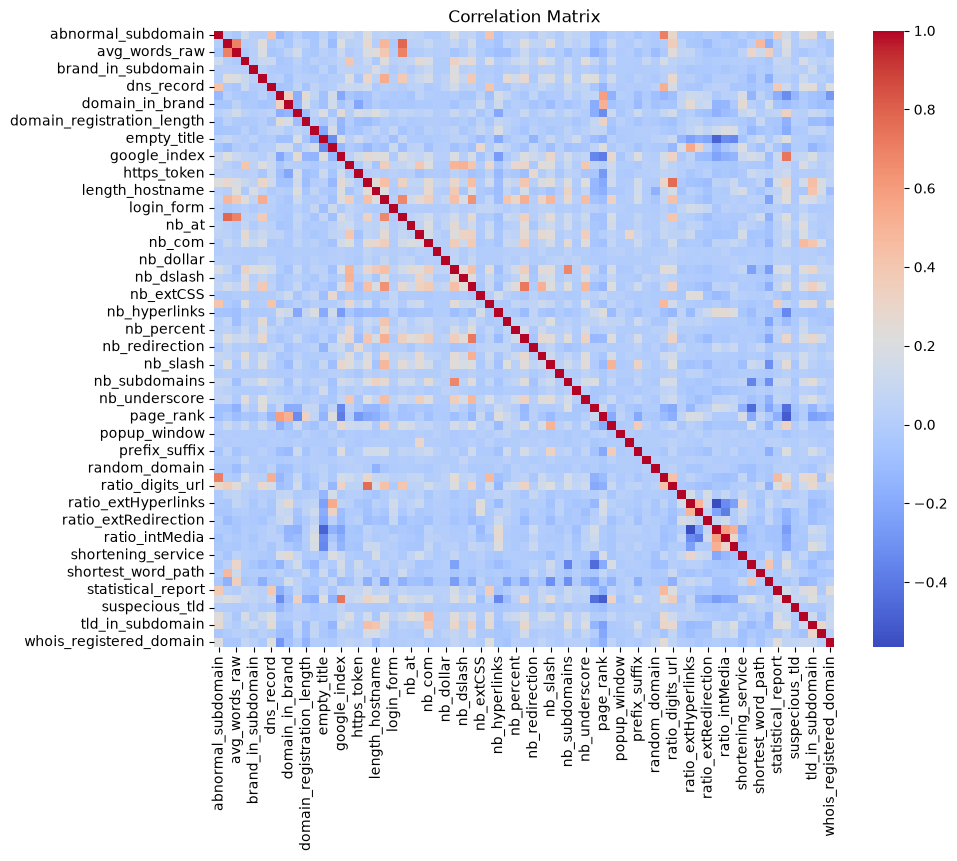

In [18]:
cleaned_data_frame_2 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_2, annotate=False)

In [19]:
get_top_correlation_pairs(cleaned_data_frame_2, 10)

avg_word_path      longest_word_path     0.783384
ip                 ratio_digits_url      0.764657
status             google_index          0.734620
nb_eq              nb_qm                 0.725301
ratio_digits_host  abnormal_subdomain    0.704427
avg_words_raw      avg_word_path         0.699656
longest_word_path  avg_words_raw         0.689232
nb_subdomains      nb_dots               0.678439
longest_word_path  length_url            0.675539
length_url         nb_eq                 0.637347
dtype: float64

In [20]:
get_correlation_to_target(
    set(cleaned_data_frame_2.columns)
)

status                 1.000000
google_index           0.734620
ratio_digits_url       0.354270
domain_in_title        0.335234
phish_hints            0.331244
                         ...   
ratio_intHyperlinks   -0.256211
domain_age            -0.323937
nb_hyperlinks         -0.342196
nb_www                -0.440457
page_rank             -0.503594
Name: status, Length: 71, dtype: float64

## Random Forest Model

In [21]:
random_forest = RandomForestClassifier(random_state=41)
test_model(random_forest, MODEL_FILE_NAME, cleaned_data_frame_2)


Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3829
           1       1.00      1.00      1.00      3829

    accuracy                           1.00      7658
   macro avg       1.00      1.00      1.00      7658
weighted avg       1.00      1.00      1.00      7658


Test Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1886
           1       0.96      0.97      0.96      1886

    accuracy                           0.96      3772
   macro avg       0.96      0.96      0.96      3772
weighted avg       0.96      0.96      0.96      3772



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",41
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Feature Importances

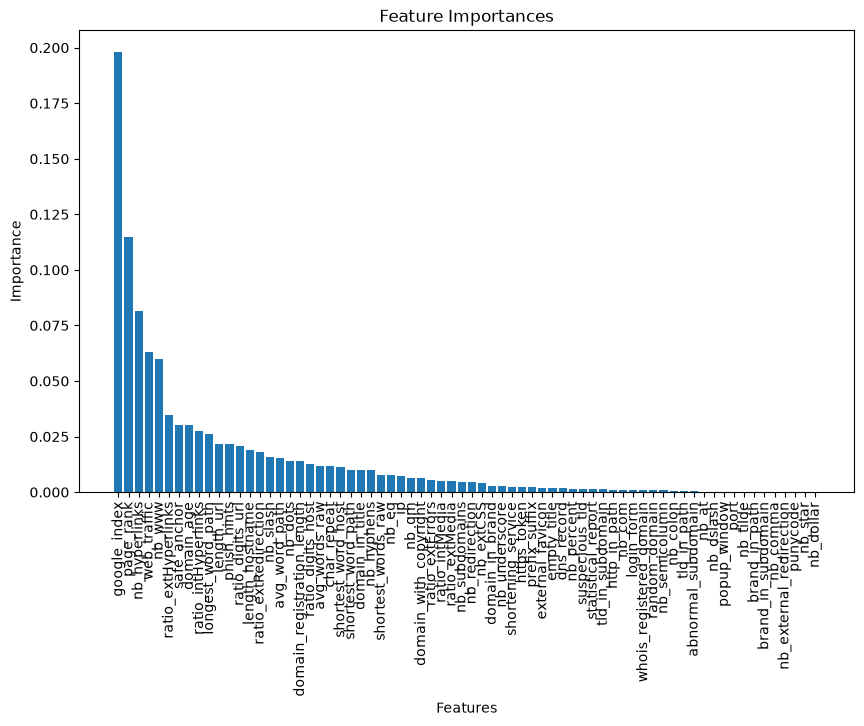

In [22]:
plot_feature_importance(random_forest)